In [2]:
import sys
import os
# Adiciona a pasta raiz do projeto (onde está a pasta src) ao sys.path
sys.path.append(os.path.abspath(os.path.join("..")))
import pandas as pd
from src.visualization.interactive_plot import *

In [101]:
tbl_simulacao = pd.read_csv('../data/simulation/sim_2025-09-24_23-37-46.csv', sep=',')

In [102]:
tbl_simulacao.describe()

,previsao_min,tempo_real_min,tempo_corrigido_min,delivery_distance,tempo_coleta,Agent_Rating,is_grocery,jam_or_high_traffic,is_sunny_weather,tempo_criacao_sim,tempo_conclusao_sim
count,6010.000000,6010.000000,6010.000000,6010.000000,6010.000000,6010.000000,6010.000000,6010.000000,6010.000000,6010.000000,6010.000000
mean,125.389039,115.482278,103.668634,9.603295,9.991681,4.696335,0.062562,0.700666,0.195674,5154.134707,5267.795021
std,29.595231,31.625040,29.403456,5.477292,4.101792,0.190567,0.242194,0.458005,0.396752,2831.146810,2831.214582
min,32.227195,1.281754,1.281754,0.000000,5.000000,4.023121,0.000000,0.000000,0.000000,5.055078,95.365693
25%,105.866278,100.284894,89.883541,5.006406,5.000000,4.559931,0.000000,0.000000,0.000000,2873.360877,2991.373526
50%,131.230633,118.963265,105.594692,8.957525,10.000000,4.702698,0.000000,1.000000,0.000000,5110.215624,5231.775150
75%,136.147785,131.664588,118.573494,14.345355,15.000000,4.840779,0.000000,1.000000,0.000000,7579.406334,7697.581880
max,203.000953,221.752203,206.752203,28.588770,15.000000,5.000000,1.000000,1.000000,1.000000,10039.189183,10079.414052


In [103]:
tbl_simulacao['res'] = tbl_simulacao['tempo_real_min'] - tbl_simulacao['previsao_min']

In [104]:
tbl_simulacao['res_corr'] = tbl_simulacao['tempo_real_min'] - tbl_simulacao['tempo_corrigido_min']

In [113]:
tbl_simulacao.query("tempo_real_min<120 and is_grocery==0 and res<-10")

,id_pedido,previsao_min,tempo_real_min,tempo_corrigido_min,delivery_distance,tempo_coleta,Agent_Rating,Vehicle,Weather,Traffic,Area,weekend,is_grocery,jam_or_high_traffic,is_sunny_weather,tempo_criacao_sim,tempo_conclusao_sim,decisao,res,res_corr
2,pedido_13.339140639229697_5,99.730215,80.469046,80.469046,6.268472,15,4.680031,Moto,Foggy,Low,Metropolitian,False,0,0,0,13.339141,108.808186,Nenhuma,-19.261170,0.0
4,pedido_44.29395629230467_16,103.339313,67.456721,52.456721,3.115935,15,4.541364,Moto,Sunny,High,Metropolitian,False,0,1,1,44.293956,111.750678,Aumento_Velocidade,-35.882592,15.0
5,pedido_5.055078023534754_0,130.774235,101.790758,101.790758,13.834724,10,4.680714,Van,Stormy,High,Metropolitian,True,0,1,0,5.055078,116.845836,Nenhuma,-28.983478,0.0
6,pedido_56.30517547009413_24,95.546211,64.788873,49.788873,8.450316,15,4.593943,Moto,Sunny,High,Metropolitian,False,0,1,1,56.305175,121.094049,Aumento_Velocidade,-30.757338,15.0
8,pedido_48.76911734162836_20,101.363591,83.804780,68.804780,16.847534,10,4.818477,Moto,Sunny,Medium,Metropolitian,False,0,0,1,48.769117,127.573897,Rota_Reduzida,-17.558811,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6002,pedido_9951.805906614813_800,136.622653,116.719811,101.719811,21.461871,15,4.867960,Moto,Sandstorms,High,Metropolitian,False,0,1,0,9951.805907,10068.525717,Aumento_Velocidade,-19.902842,15.0
6003,pedido_9947.958473227218_798,131.573454,106.042656,106.042656,1.974056,15,5.000000,Van,Stormy,High,Urban,False,0,1,0,9947.958473,10069.001129,Nenhuma,-25.530798,0.0
6004,pedido_9979.233915231844_818,97.093921,75.603583,75.603583,4.946105,15,4.729472,Scooter,Sunny,Low,Metropolitian,True,0,0,1,9979.233915,10069.837498,Nenhuma,-21.490338,0.0
6005,pedido_9940.253287028792_793,133.681029,114.712233,114.712233,14.524880,15,4.518613,Van,Windy,High,Metropolitian,True,0,1,0,9940.253287,10069.965520,Nenhuma,-18.968796,0.0


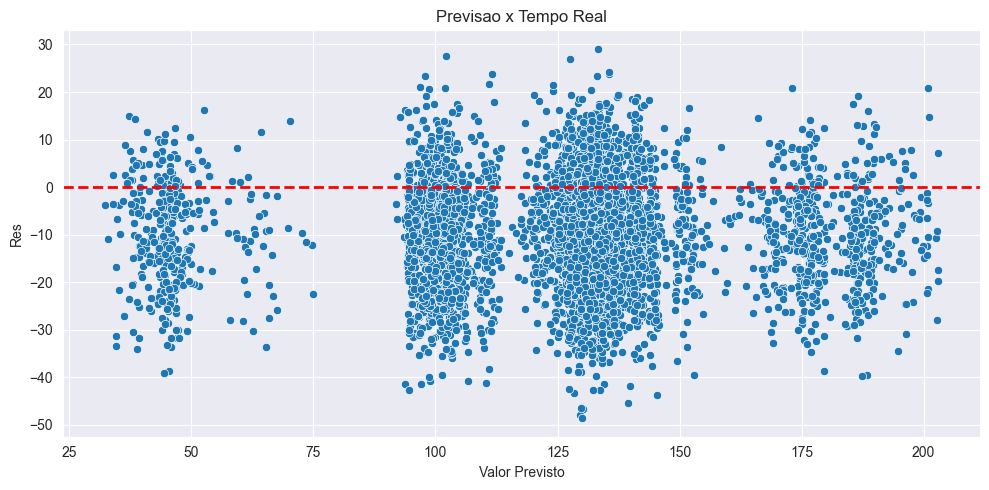

In [106]:
grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['res'],
                          x=tbl_simulacao['previsao_min'],
                          titulo='Previsao x Tempo Real', ylabel='Res', xlabel='Valor Previsto',res=True)

<Axes: >

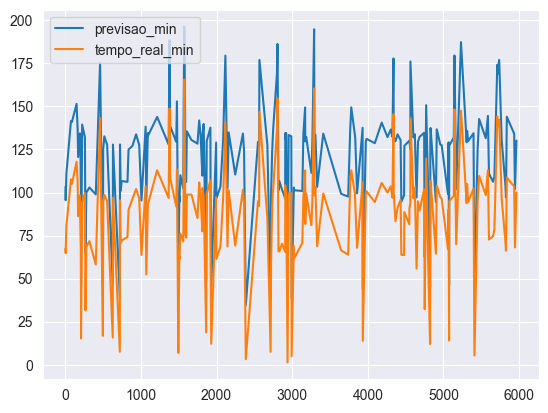

In [107]:
tbl_simulacao[tbl_simulacao.res<-30][['previsao_min','tempo_real_min',]].plot(kind='line')

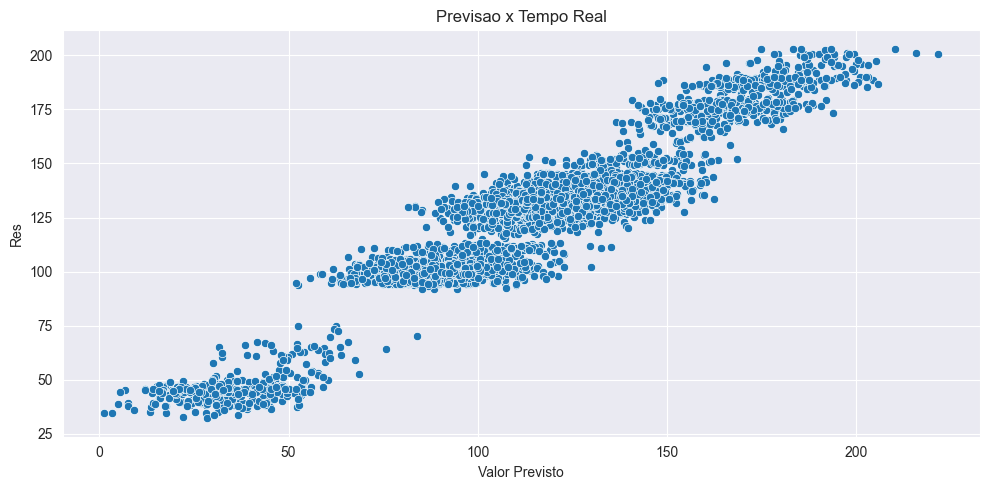

In [108]:
grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['previsao_min'],
                          x=tbl_simulacao['tempo_real_min'],
                          titulo='Previsao x Tempo Real', ylabel='Res', xlabel='Valor Previsto')

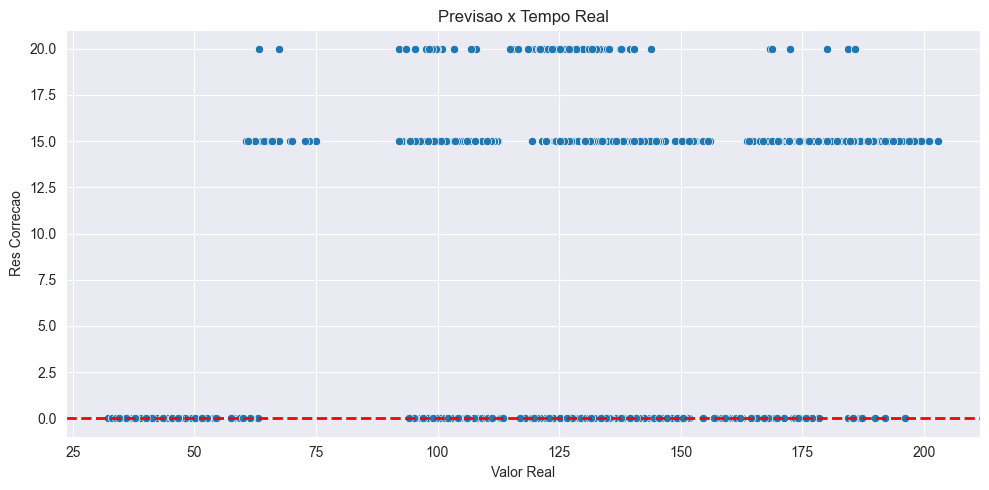

In [109]:
grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['res_corr'],
                          x=tbl_simulacao['previsao_min'],
                          titulo='Previsao x Tempo Real', ylabel='Res Correcao', xlabel='Valor Real',res=True)

<Axes: >

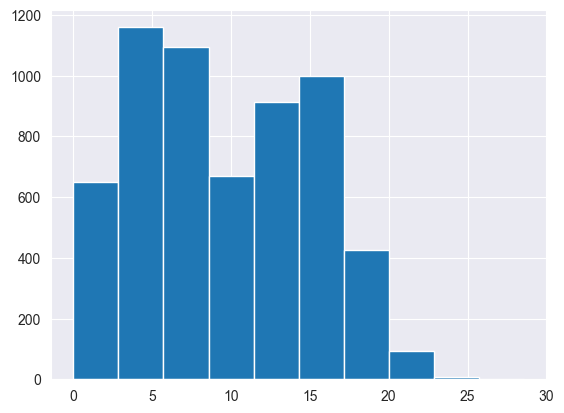

In [110]:
tbl_simulacao.delivery_distance.hist()

In [111]:
otd_corrigido = (tbl_simulacao['tempo_real_min'] <= 120).mean()
otd_corrigido

np.float64(0.51846921797005)

In [112]:
otd_corrigido = (tbl_simulacao['tempo_corrigido_min'] <= 120).mean()
otd_corrigido

np.float64(0.7708818635607321)